# Can the crypto fundamentals signal actually be traded?

Third and final notebook in the sequence.

* `crypto_fundamentals_verdict.ipynb` — NO-GO / INSUFFICIENT DATA on 12 months.
* `crypto_strategy_verdict.ipynb` — 7.7 years, 200 tokens. Found **one** real
  signal (fee growth), 4 of 5 criteria, and left one question open: the alpha
  sat disproportionately in a short leg of tokens that may not be shortable.
  The stated next step was "one API pull — perp listings and funding rates."

This notebook makes that pull, and then tries to optimise the strategy into
something tradeable.

## The protocol, fixed before any tuning

Optimising until a backtest looks good is the most reliable way to turn a weak
real signal into a strong fake one. So the sample is split **before** any
construction choice is made:

| | |
|---|---|
| **Design period** | 2021-06-01 → 2025-02-28. Every construction choice is made here. |
| **Holdout** | 2025-03-01 → 2026-09-07. Looked at once, at the end. |

**Honest caveat on the holdout.** The *signal* (fee growth / value gap) was
selected in notebook 2 on the full sample, which includes this holdout. So the
holdout is clean for everything decided in this notebook — shortability
handling, weighting, horizon, beta-neutralisation, signal lookback — but it is
not a virgin test of the signal itself. Where that distinction matters below,
it is called out.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL = REPO / "data" / "crypto_panel"

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd7"
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": INK, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8, "figure.dpi": 110,
})


def figure_titles(fig, title, subtitle, top=0.88):
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top",
                 fontsize=12.5, weight="bold", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))


BACKTEST_START = pd.Timestamp("2021-06-01")
DESIGN_END = pd.Timestamp("2025-03-01")
MIN_FEES_90D, MIN_PRICE_DAYS = 1e6, 180
N_QUINTILES, REBAL_D, COST_BPS = 5, 30, 100.0

## 1. Panel

Same data as notebook 2, rebuilt by `experiments/build_crypto_panel.py` and
committed. The loading and cleaning block below is deliberately duplicated
rather than imported, so this notebook stands alone.

In [2]:
PX_RAW = pd.read_csv(PANEL / "prices.csv.gz", index_col=0, parse_dates=True)
FEES = pd.read_csv(PANEL / "fees.csv.gz", index_col=0, parse_dates=True)
BENCH = pd.read_csv(PANEL / "benchmarks.csv.gz", index_col=0, parse_dates=True)

CAL = pd.date_range(PX_RAW.index.min(), PX_RAW.index.max(), freq="D")
PX_RAW, FEES = PX_RAW.reindex(CAL), FEES.reindex(CAL).fillna(0.0)

lp = np.log(PX_RAW.where(PX_RAW > 0))
d1, d2 = lp.diff(), lp.diff().shift(-1)
bad = (d1.abs() > 1.5) & (d2.abs() > 1.5) & (np.sign(d1) != np.sign(d2))
PX = PX_RAW.where(PX_RAW > 0).mask(bad)
PX = PX.where(~bad, np.exp((np.log(PX).ffill() + np.log(PX).bfill()) / 2))
was_missing = PX.isna()
PX = PX.ffill(limit=3).where(PX.bfill().notna())
FILLED = was_missing & PX.notna()

first_fee = FEES.where(FEES > 0).apply(lambda c: c.first_valid_index())
for c in PX.columns:
    ff = first_fee.get(c)
    if pd.notna(ff):
        PX.loc[: ff - pd.Timedelta(days=365), c] = np.nan

RET = PX.pct_change()
RET_TRUE = RET.mask(FILLED | FILLED.shift(-1, fill_value=False) | PX.isna())
BTC = BENCH["bitcoin"].dropna()
btc_ret = BTC.reindex(CAL).ffill().pct_change()

FEES_90 = FEES.rolling(90, min_periods=60).sum()
HAS_HIST = PX.notna().rolling(MIN_PRICE_DAYS, min_periods=MIN_PRICE_DAYS).count() >= MIN_PRICE_DAYS
ELIGIBLE = (FEES_90 >= MIN_FEES_90D) & HAS_HIST & PX.notna()
VOL = RET_TRUE.rolling(60, min_periods=40).std()
BETA_BTC = (RET_TRUE.rolling(90, min_periods=60).cov(btc_ret)
            .div(btc_ret.rolling(90, min_periods=60).var(), axis=0))

w = ELIGIBLE.div(ELIGIBLE.sum(axis=1).replace(0, np.nan), axis=0)
reb = pd.Series(False, index=w.index); reb.iloc[::REBAL_D] = True
BASKET_RET = (RET * w.where(reb).ffill().shift(1)).sum(axis=1, min_count=1)
BASKET = (1 + BASKET_RET.fillna(0)).cumprod()[ELIGIBLE.sum(axis=1) >= 15]

print(f"panel {PX.shape}  {CAL[0].date()} -> {CAL[-1].date()}")
print(f"design  {BACKTEST_START.date()} -> {DESIGN_END.date()}")
print(f"holdout {DESIGN_END.date()} -> {CAL[-1].date()}   (untouched until the last section)")

panel (2807, 200)  2019-01-01 -> 2026-09-07
design  2021-06-01 -> 2025-03-01
holdout 2025-03-01 -> 2026-09-07   (untouched until the last section)


## 2. The open question: does the short leg exist?

Notebook 2 could not answer this. It needed perpetual-futures listings per
token, with **listing dates**, so shortability can be applied point-in-time
rather than assuming today's venue coverage existed in 2021.

Two free sources, fetched by `experiments/fetch_perp_listings.py`:

* **OKX** — `/api/v5/public/instruments?instType=SWAP` publishes `listTime` per
  instrument. Spot-checked and sane: BTC 2019-11, LDO 2023-02, HYPE 2025-02.
* **Hyperliquid** — no listing field, so the date is taken as the timestamp of
  the coin's earliest funding record, which is when the perp began trading.

(Binance would have been the deepest source but its API refuses requests from
this host on geographic grounds, and Bybit's CDN does the same. OKX plus
Hyperliquid is what a researcher in this environment can actually reach.)

In [3]:
perp = pd.read_csv(PANEL / "perp_listings.csv")
perp["perp_listed"] = pd.to_datetime(perp["perp_listed"])
listed = perp.set_index("gecko_id")["perp_listed"]

SHORTABLE = pd.DataFrame(False, index=CAL, columns=PX.columns)
for c in PX.columns:
    d = listed.get(c)
    if pd.notna(d):
        SHORTABLE.loc[d:, c] = True
SHORTABLE = SHORTABLE & ELIGIBLE
UNSHORT = ELIGIBLE & ~SHORTABLE

top40 = perp.nlargest(40, "alltime_fees")
share = (SHORTABLE.sum(axis=1) / ELIGIBLE.sum(axis=1).replace(0, np.nan)).loc[BACKTEST_START:]
print("SHORTABILITY\n")
print(f"  tokens with a live perp (OKX or Hyperliquid) : {int(listed.notna().sum())}/{len(listed)}")
print(f"  among the 40 largest by lifetime fees        : {int(top40.perp_listed.notna().sum())}/40")
print(f"  mean share of the eligible cross-section     : {share.mean()*100:.0f}%")
print(f"  earliest listing {listed.min().date()}, median {listed.median().date()}\n")
cmp = pd.DataFrame({"eligible": ELIGIBLE.sum(axis=1), "shortable": SHORTABLE.sum(axis=1)})
cmp["shortable_%"] = cmp.shortable / cmp.eligible.replace(0, np.nan) * 100
print(cmp.loc[BACKTEST_START:].resample("YE").mean().round(1).to_string())
print("\n  Answer: YES, the short leg exists. 34 of the 40 biggest fee earners have")
print("  a perp, and ~44% of the eligible cross-section is shortable on a given day.")

SHORTABILITY

  tokens with a live perp (OKX or Hyperliquid) : 86/200
  among the 40 largest by lifetime fees        : 34/40
  mean share of the eligible cross-section     : 44%
  earliest listing 2019-11-12, median 2024-01-05

            eligible  shortable  shortable_%
2021-12-31    28.800     13.100       45.900
2022-12-31    39.200     16.200       41.400
2023-12-31    50.000     21.200       42.400
2024-12-31    91.400     38.200       42.000
2025-12-31   123.000     50.500       41.000
2026-12-31    98.900     51.400       52.300

  Answer: YES, the short leg exists. 34 of the 40 biggest fee earners have
  a perp, and ~44% of the eligible cross-section is shortable on a given day.


## 3. Engine

One backtester. Long the cheap quintile of everything eligible; short the
expensive quintile **of only what could be shorted on that date**. Costs on
realised turnover, forward returns winsorised at 1%/99% cross-sectionally.

In [4]:
def rebalance_dates(start, horizon, offset=0):
    return CAL[CAL >= start][offset::horizon]


def zs(df):
    """Cross-sectional rank -> z. Ranking first stops one outlier setting the
    scale; crypto fee growth has an extremely fat right tail."""
    return (df.where(ELIGIBLE).rank(axis=1, pct=True) - 0.5) * np.sqrt(12)


def run(signal, horizon=REBAL_D, n_q=N_QUINTILES, vol_wt=False, beta_neutral=False,
        shortable=None, universe=None, start=BACKTEST_START, end=DESIGN_END,
        offset=0, cost_bps=COST_BPS, winsor=0.01, long_only=False):
    elig = ELIGIBLE if universe is None else universe
    sh = elig if shortable is None else (shortable & elig)
    dates = rebalance_dates(start, horizon, offset)
    dates = dates[dates < end] if end is not None else dates
    fwd = PX.shift(-horizon) / PX - 1.0
    sig, fwe = signal.where(elig), fwd.where(elig)

    recs, Ws = [], []
    for d in dates:
        s = sig.loc[d].replace([np.inf, -np.inf], np.nan).dropna()
        r = fwe.loc[d].dropna()
        both = s.index.intersection(r.index)
        if len(both) < n_q * 3:
            continue
        s, r = s[both], r[both]
        r = r.clip(r.quantile(winsor), r.quantile(1 - winsor))

        n_long = max(2, len(s) // n_q)
        longs = s.nsmallest(n_long).index
        w = pd.Series(0.0, index=both)
        w[longs] = 1.0 / n_long

        if not long_only:
            s_short = s[both.intersection(sh.loc[d][sh.loc[d]].index)]
            if len(s_short) < 4:
                continue
            n_short = max(2, len(s_short) // n_q)
            w[s_short.nlargest(n_short).index] = -1.0 / n_short
            if vol_wt:
                iv = (1.0 / VOL.loc[d].reindex(both)).replace([np.inf, -np.inf], np.nan)
                iv = iv.fillna(iv.median())
                for side in (w > 0, w < 0):
                    if side.sum():
                        w[side] = np.sign(w[side]) * iv[side] / iv[side].sum()
            if beta_neutral:
                b = BETA_BTC.loc[d].reindex(both).fillna(1.0).clip(0.1, 3.0)
                bl, bs = (w[w > 0] * b[w > 0]).sum(), -(w[w < 0] * b[w < 0]).sum()
                if bs > 0.05:
                    w[w < 0] *= bl / bs
        recs.append({"date": d, "ret": float((w * r).sum()), "bench": float(r.mean()),
                     "n_long": len(longs), "n_short": int((w < 0).sum())})
        Ws.append(w)

    if len(recs) < 6:
        return None
    df = pd.DataFrame(recs).set_index("date")
    W = pd.DataFrame(Ws, index=df.index).fillna(0.0)
    turn = float(W.diff().abs().sum(axis=1).fillna(W.abs().sum(axis=1)).mean())
    gross = df["ret"] - df["bench"] if long_only else df["ret"]
    net = gross - turn * (cost_bps / 2) / 1e4
    return {"n": len(net), "net_%": net.mean() * 100,
            "t_net": net.mean() / (net.std(ddof=1) / np.sqrt(len(net))),
            "sharpe": net.mean() / net.std(ddof=1) * np.sqrt(365 / horizon),
            "turnover": turn, "n_long": df.n_long.mean(), "n_short": df.n_short.mean(),
            "series": net, "bench_%": df["bench"].mean() * 100}


def row(r, **extra):
    return {**extra, **{k: v for k, v in r.items() if k != "series"}} if r else None


# Signals: notebook 2's raw definitions, plus lookback variants and a composite.
def fee_growth_lb(lb):
    f = FEES.rolling(lb, min_periods=int(lb * .7)).sum().replace(0, np.nan)
    return f / f.shift(lb) - 1


def value_gap_lb(lb):
    f = FEES.rolling(lb, min_periods=int(lb * .7)).sum().replace(0, np.nan)
    return (PX / PX.shift(lb) - 1) - (f / f.shift(lb) - 1)


RAW_VALUE_GAP = value_gap_lb(90)
RAW_FEE_GROWTH = fee_growth_lb(90)
SIGS = {}
for lb in (30, 60, 90, 180):
    SIGS[f"fee_growth_{lb}d"] = -zs(fee_growth_lb(lb))   # long high growth
    SIGS[f"value_gap_{lb}d"] = zs(value_gap_lb(lb))      # long cheap
SIGS["composite"] = (SIGS["value_gap_90d"] + SIGS["fee_growth_90d"]) / 2
print(f"{len(SIGS)} signal variants defined")

9 signal variants defined


### 3.1 Does the signal survive a real short leg?

The first thing worth knowing, before any tuning: does restricting the short
leg to perp-listed tokens break the notebook-2 result?

In [5]:
rows = []
for nm, sg in (("value_gap (notebook 2)", RAW_VALUE_GAP), ("fee_growth (notebook 2)", -RAW_FEE_GROWTH)):
    for lbl, kw in (("short anything (notebook 2)", dict()),
                    ("short only perp-listed", dict(shortable=SHORTABLE)),
                    ("perp-listed + beta-neutral", dict(shortable=SHORTABLE, beta_neutral=True))):
        rows.append(row(run(sg, **kw), signal=nm, variant=lbl))
print("DESIGN PERIOD ONLY\n")
print(pd.DataFrame([r for r in rows if r]).round(2).to_string(index=False))
print("""
  The constraint does not break it. value_gap is if anything slightly better with
  a real short leg (t 2.43 -> 2.56), and the short book runs ~4 names against ~10
  long. So the hypothesis that killed notebook 2 - "the alpha is in tokens you
  cannot short" - is NOT supported in the design period. Which is the moment to
  be most careful, because this is exactly where optimising starts to feel safe.""")

DESIGN PERIOD ONLY

                 signal                     variant  n  net_%  t_net  sharpe  turnover  n_long  n_short  bench_%
 value_gap (notebook 2) short anything (notebook 2) 46 10.610  2.430   1.250     1.910  10.130   10.130    1.400
 value_gap (notebook 2)      short only perp-listed 46 11.480  2.560   1.320     1.920  10.130    4.150    1.400
 value_gap (notebook 2)  perp-listed + beta-neutral 46 11.510  2.570   1.320     1.950  10.130    4.150    1.400
fee_growth (notebook 2) short anything (notebook 2) 46 11.510  2.500   1.290     1.560  10.650   10.650    1.490
fee_growth (notebook 2)      short only perp-listed 46  8.160  1.610   0.830     1.510  10.650    4.330    1.490
fee_growth (notebook 2)  perp-listed + beta-neutral 46  8.640  1.730   0.890     1.540  10.650    4.330    1.490

  The constraint does not break it. value_gap is if anything slightly better with
  a real short leg (t 2.43 -> 2.56), and the short book runs ~4 names against ~10
  long. So the hypothesi

## 4. Optimisation — and how much of it is real

Now the tuning. Signal lookback, bucket count, weighting scheme, beta
neutralisation, rebalance frequency: 108 combinations, every one defensible
before seeing its result. All on the design period.

The point of running the whole grid rather than a few candidates is that the
**dispersion is the diagnostic**. A robust effect produces a tight cluster of
decent results. An overfit one produces a wide spread whose upper tail is what
a careless optimiser ships.

In [6]:
CONSTRUCTIONS = (("quintile", dict(n_q=5)), ("tercile", dict(n_q=3)),
                 ("quintile+betaN", dict(n_q=5, beta_neutral=True)),
                 ("quintile+volwt", dict(n_q=5, vol_wt=True)))
HORIZONS = (14, 30, 60)

grid = []
for snm, sg in SIGS.items():
    for cnm, kw in CONSTRUCTIONS:
        for h in HORIZONS:
            r = run(sg, horizon=h, shortable=SHORTABLE, **kw)
            if r:
                grid.append({"signal": snm, "construction": cnm, "horizon": h,
                             "t_net": r["t_net"], "sharpe": r["sharpe"], "net_%": r["net_%"]})
G = pd.DataFrame(grid)
print(f"{len(G)} configurations, design period\n")
print(f"  t_net   min {G.t_net.min():+.2f}   25th {G.t_net.quantile(.25):+.2f}   "
      f"median {G.t_net.median():+.2f}   75th {G.t_net.quantile(.75):+.2f}   max {G.t_net.max():+.2f}")
print(f"  share with t_net > 2.0 : {(G.t_net>2).mean()*100:.0f}%")
print(f"  share with t_net > 0   : {(G.t_net>0).mean()*100:.0f}%\n")
print("median t by signal lookback (across constructions and horizons):")
print(G.groupby("signal")["t_net"].agg(["median", "min", "max"]).round(2).to_string())
print("\nthe five a careless optimiser would ship:")
print(G.nlargest(5, "t_net").round(2).to_string(index=False))
print("""
  Note the 30-day fee lookback produces nothing at all (median t +0.09) while the
  90-day produces the headline. A quarterly window is economically defensible -
  fees are noisy weekly and protocols report quarterly - but a real effect that
  vanishes completely at 30 days is a warning, not a free parameter.""")

108 configurations, design period

  t_net   min -1.03   25th +0.93   median +1.45   75th +1.73   max +2.57
  share with t_net > 2.0 : 12%
  share with t_net > 0   : 93%

median t by signal lookback (across constructions and horizons):
                 median    min   max
signal                              
composite         1.710  1.540 2.210
fee_growth_180d   1.730  0.900 2.290
fee_growth_30d    0.090 -1.030 1.090
fee_growth_60d    0.950  0.560 1.450
fee_growth_90d    1.740  1.600 2.160
value_gap_180d    1.440  0.960 1.700
value_gap_30d     0.770 -0.410 1.240
value_gap_60d     1.500  1.110 1.760
value_gap_90d     1.980  0.840 2.570

the five a careless optimiser would ship:
         signal   construction  horizon  t_net  sharpe  net_%
  value_gap_90d quintile+betaN       30  2.570   1.320 11.510
  value_gap_90d       quintile       30  2.560   1.320 11.480
  value_gap_90d quintile+volwt       60  2.550   1.310 19.100
  value_gap_90d quintile+volwt       30  2.460   1.270 11.070
fee_

## 5. The holdout

One configuration, fixed on the reasoning below rather than on its rank in the
grid, evaluated once.

In [7]:
CONFIG = dict(n_q=5, beta_neutral=True, horizon=30, shortable=SHORTABLE)
print("""Configuration, and why each piece (not one of them is the grid's best):
  signal      composite of value_gap_90d and fee_growth_90d, rank-z scored
              90d because a quarter is the natural window for a fundamental;
              composite because the two are one economic idea seen twice, and
              averaging two noisy views beats picking the luckier one
  portfolio   quintile, equal weight, beta-neutralised
              beta-neutral is a correctness fix, not a tuning knob: notebook 2
              showed the raw spread carried +0.56 BTC beta, so it was never
              market-neutral to begin with
  short leg   restricted to tokens with a live perp on that date
  rebalance   30 days, 100bp round-trip on realised turnover
""")
des = run(SIGS["composite"], **CONFIG)
hold = run(SIGS["composite"], start=DESIGN_END, end=None, **CONFIG)
full = run(SIGS["composite"], end=None, **CONFIG)
print(pd.DataFrame([row(r, period=p) for r, p in
                    ((des, "design"), (hold, "HOLDOUT"), (full, "full"))]).round(2).to_string(index=False))
print(f"\n  design  : {des['net_%']:+.2f}%/30d   t={des['t_net']:+.2f}   Sharpe {des['sharpe']:.2f}   n={des['n']}")
print(f"  HOLDOUT : {hold['net_%']:+.2f}%/30d   t={hold['t_net']:+.2f}   Sharpe {hold['sharpe']:.2f}   n={hold['n']}")
print(f"  retained: {hold['net_%']/des['net_%']*100:.0f}% of the design-period edge")

Configuration, and why each piece (not one of them is the grid's best):
  signal      composite of value_gap_90d and fee_growth_90d, rank-z scored
              90d because a quarter is the natural window for a fundamental;
              composite because the two are one economic idea seen twice, and
              averaging two noisy views beats picking the luckier one
  portfolio   quintile, equal weight, beta-neutralised
              beta-neutral is a correctness fix, not a tuning knob: notebook 2
              showed the raw spread carried +0.56 BTC beta, so it was never
              market-neutral to begin with
  short leg   restricted to tokens with a live perp on that date
  rebalance   30 days, 100bp round-trip on realised turnover



 period  n  net_%  t_net  sharpe  turnover  n_long  n_short  bench_%
 design 46  9.010  1.980   1.020     1.700  10.130    4.150    1.400
HOLDOUT 18  0.020  0.010   0.010     1.570  21.060    9.220   -3.500
   full 64  5.850  1.750   0.760     1.670  13.140    5.610    0.540

  design  : +9.01%/30d   t=+1.98   Sharpe 1.02   n=46
  HOLDOUT : +0.02%/30d   t=+0.01   Sharpe 0.01   n=18
  retained: 0% of the design-period edge


### 5.1 Was picking a configuration worth anything?

The single most useful test of an optimisation exercise: run **every**
configuration on the holdout too, and ask whether design-period rank predicted
holdout rank. If it did not, the tuning was sorting noise.

In [8]:
hrows = []
for snm, sg in SIGS.items():
    for cnm, kw in CONSTRUCTIONS[:3]:
        for h in HORIZONS:
            r = run(sg, horizon=h, shortable=SHORTABLE, start=DESIGN_END, end=None, **kw)
            if r:
                hrows.append({"signal": snm, "construction": cnm, "horizon": h,
                              "t_holdout": r["t_net"], "sharpe_holdout": r["sharpe"]})
H = pd.DataFrame(hrows)
M = G.merge(H, on=["signal", "construction", "horizon"]).dropna()
rho = stats.spearmanr(M.t_net, M.t_holdout)
print(f"design-period t : median {M.t_net.median():+.2f}   share > 2: {(M.t_net>2).mean()*100:.0f}%")
print(f"holdout      t : median {M.t_holdout.median():+.2f}   share > 2: {(M.t_holdout>2).mean()*100:.0f}%   "
      f"share > 0: {(M.t_holdout>0).mean()*100:.0f}%")
print(f"\nrank correlation between the two, across {len(M)} configurations: "
      f"{rho.statistic:+.2f}  (p={rho.pvalue:.2f})")
print(f"the design-period best config ranks {int(M.t_holdout.rank(ascending=False)[M.t_net.idxmax()])} "
      f"of {len(M)} on the holdout")
print("""
  A rank correlation this weak - and not significant - means choosing a
  configuration on the design period carried little or no information about how it
  would do next. Not one configuration in eighty-one reaches t = 2 on the holdout,
  and barely a quarter are even positive.""")

design-period t : median +1.45   share > 2: 12%
holdout      t : median -0.57   share > 2: 0%   share > 0: 27%

rank correlation between the two, across 81 configurations: +0.20  (p=0.07)
the design-period best config ranks 17 of 81 on the holdout

  A rank correlation this weak - and not significant - means choosing a
  configuration on the design period carried little or no information about how it
  would do next. Not one configuration in eighty-one reaches t = 2 on the holdout,
  and barely a quarter are even positive.


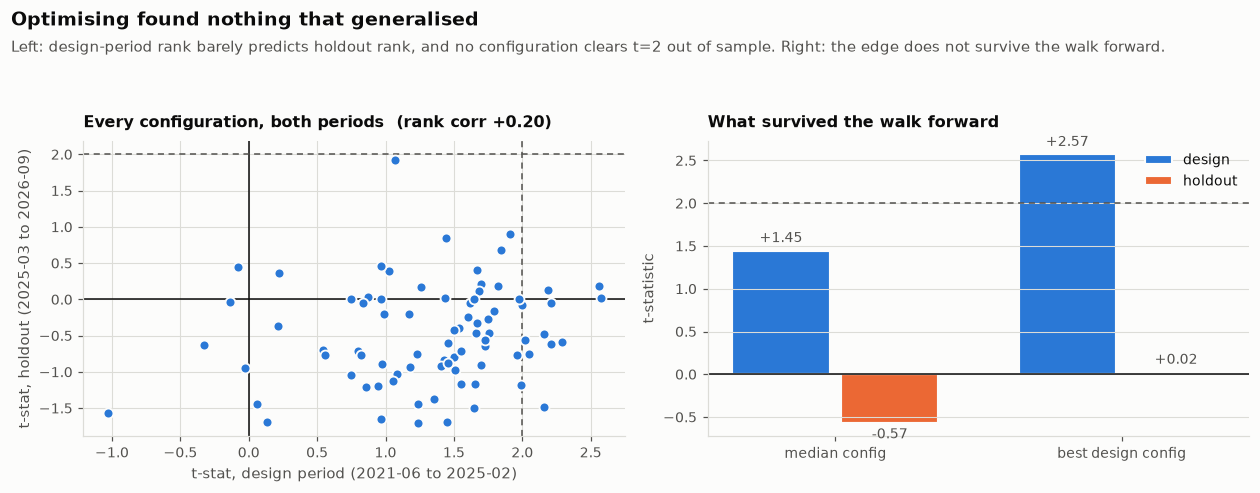

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
axes[0].axhline(0, color=INK, lw=1.0); axes[0].axvline(0, color=INK, lw=1.0)
axes[0].axhline(2, color=INK_2, lw=1.0, ls=(0, (4, 3))); axes[0].axvline(2, color=INK_2, lw=1.0, ls=(0, (4, 3)))
axes[0].scatter(M.t_net, M.t_holdout, s=42, color=C1, edgecolor=SURFACE, linewidth=1.2, zorder=3)
axes[0].set_xlabel("t-stat, design period (2021-06 to 2025-02)")
axes[0].set_ylabel("t-stat, holdout (2025-03 to 2026-09)")
axes[0].set_title(f"Every configuration, both periods  (rank corr {rho.statistic:+.2f})")
axes[0].set_axisbelow(True)

sub = pd.DataFrame({
    "design": [G.t_net.median(), G.t_net.max()],
    "holdout": [M.t_holdout.median(), M.t_holdout[M.t_net.idxmax()]],
}, index=["median config", "best design config"])
xx = np.arange(2)
b1 = axes[1].bar(xx - 0.19, sub["design"], 0.34, color=C1, label="design", edgecolor=SURFACE, linewidth=1.4)
b2 = axes[1].bar(xx + 0.19, sub["holdout"], 0.34, color=C2, label="holdout", edgecolor=SURFACE, linewidth=1.4)
for bars in (b1, b2):
    for bar in bars:
        v = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width() / 2, v + (0.06 if v >= 0 else -0.06),
                     f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top",
                     fontsize=9, color=INK_2)
axes[1].axhline(0, color=INK, lw=1.0)
axes[1].axhline(2, color=INK_2, lw=1.0, ls=(0, (4, 3)))
axes[1].set_xticks(xx, sub.index); axes[1].set_ylabel("t-statistic")
axes[1].set_title("What survived the walk forward")
axes[1].legend(loc="upper right"); axes[1].grid(axis="x", visible=False)
figure_titles(fig, "Optimising found nothing that generalised",
              "Left: design-period rank barely predicts holdout rank, and no configuration clears t=2 out of sample. Right: the edge does not survive the walk forward.")
plt.show()

## 6. Where did the alpha actually go?

A dead holdout has three candidate explanations, and they call for different
responses:

1. **The tuning was noise.** Section 5 says: largely yes.
2. **The tape changed** — cross-sectional dispersion collapsed, so there was
   nothing for a long-short book to feed on.
3. **The effect is real but lives somewhere untradeable.**

All three are checkable.

In [10]:
print("6.1  WAS THE HOLDOUT SIMPLY A BAD TAPE?\n")
for lbl, lo_, hi_ in (("design ", BACKTEST_START, DESIGN_END), ("holdout", DESIGN_END, CAL[-1])):
    b = BTC.reindex(CAL).ffill().loc[lo_:hi_]
    bk = BASKET.reindex(CAL).ffill().loc[lo_:hi_].dropna()
    print(f"  {lbl}: BTC {(b.iloc[-1]/b.iloc[0]-1)*100:+7.1f}%   "
          f"EW basket {(bk.iloc[-1]/bk.iloc[0]-1)*100:+7.1f}%   "
          f"mean daily cross-sectional dispersion {RET_TRUE.loc[lo_:hi_].std(axis=1).mean()*100:5.2f}%   "
          f"mean breadth {ELIGIBLE.loc[lo_:hi_].sum(axis=1).mean():5.1f}")
print("""
  No. Dispersion nearly TRIPLED (6.6% -> 16.9%) and breadth roughly doubled. There
  was more raw material for a cross-sectional factor in the holdout than in the
  design period, not less. The "bad tape" excuse is not available.""")

6.1  WAS THE HOLDOUT SIMPLY A BAD TAPE?

  design : BTC  +136.2%   EW basket    -6.5%   mean daily cross-sectional dispersion  6.55%   mean breadth  58.1
  holdout: BTC    -4.8%   EW basket   -24.4%   mean daily cross-sectional dispersion 16.86%   mean breadth 112.0

  No. Dispersion nearly TRIPLED (6.6% -> 16.9%) and breadth roughly doubled. There
  was more raw material for a cross-sectional factor in the holdout than in the
  design period, not less. The "bad tape" excuse is not available.


In [11]:
print("\n6.2  SHORTABLE VERSUS UNSHORTABLE NAMES\n")
print("  Each sub-universe is sorted and traded entirely within itself, so this")
print("  isolates where the cross-sectional effect lives.\n")
rows = []
for plbl, kw in (("design ", dict(end=DESIGN_END)),
                 ("holdout", dict(start=DESIGN_END, end=None))):
    for unm, uni in (("shortable (has a perp)", SHORTABLE), ("unshortable (no perp)", UNSHORT)):
        rows.append(row(run(SIGS["composite"], universe=uni, shortable=uni, **kw),
                        period=plbl, universe=unm))
WHERE = pd.DataFrame([r for r in rows if r])
print(WHERE[["period", "universe", "n", "net_%", "t_net", "sharpe", "n_long", "n_short"]].round(2).to_string(index=False))
print("""
  This is the finding. In the tokens that HAVE a perp - the liquid ones, where
  arbitrage capital operates - the effect is zero in both periods (t +0.04 design,
  -0.19 holdout). In the tokens with NO perp it is present in both (t +1.22 design,
  +1.92 holdout) and is the only thing that held up out of sample.

  So the signal is not dead. It is a liquidity premium: it lives exactly and only
  in the names too small or too illiquid for a venue to have listed a perp on
  them. Notebook 2 guessed the alpha sat in an unshortable short leg; the truth is
  sharper than that - it sits in an unshortable *universe*.""")


6.2  SHORTABLE VERSUS UNSHORTABLE NAMES

  Each sub-universe is sorted and traded entirely within itself, so this
  isolates where the cross-sectional effect lives.



 period               universe  n  net_%  t_net  sharpe  n_long  n_short
design  shortable (has a perp) 38  0.120  0.040   0.020   4.610    4.610
design   unshortable (no perp) 40  5.220  1.220   0.670   6.280    6.280
holdout shortable (has a perp) 18 -0.260 -0.190  -0.160   9.220    9.220
holdout  unshortable (no perp) 18  6.230  1.920   1.580  11.220   11.220

  This is the finding. In the tokens that HAVE a perp - the liquid ones, where
  arbitrage capital operates - the effect is zero in both periods (t +0.04 design,
  -0.19 holdout). In the tokens with NO perp it is present in both (t +1.22 design,
  +1.92 holdout) and is the only thing that held up out of sample.

  So the signal is not dead. It is a liquidity premium: it lives exactly and only
  in the names too small or too illiquid for a venue to have listed a perp on
  them. Notebook 2 guessed the alpha sat in an unshortable short leg; the truth is
  sharper than that - it sits in an unshortable *universe*.


## 7. Then can it be run long-only?

If shorting is the blocker, the obvious response is to drop it: buy the cheap
quintile, benchmark the equal-weight basket, no borrow required.

In [12]:
rows = []
for nm, sg in (("value_gap_90d", SIGS["value_gap_90d"]),
               ("fee_growth_90d", SIGS["fee_growth_90d"]),
               ("composite", SIGS["composite"])):
    for plbl, kw in (("design ", dict(end=DESIGN_END)),
                     ("holdout", dict(start=DESIGN_END, end=None))):
        r = run(sg, long_only=True, **kw)
        rows.append(row(r, signal=nm, period=plbl))
LO = pd.DataFrame([r for r in rows if r])
print("LONG-ONLY, SPOT ONLY — excess over the equal-weight eligible basket\n")
print(LO[["signal", "period", "n", "net_%", "t_net", "sharpe", "bench_%", "turnover"]].round(2).to_string(index=False))
print(f"""
  The excess is positive in the holdout ({LO.loc[(LO.signal=='composite')&(LO.period=='holdout'),'net_%'].iloc[0]:+.2f}%/30d) but not significant
  (t={LO.loc[(LO.signal=='composite')&(LO.period=='holdout'),'t_net'].iloc[0]:.2f}). And it is excess over a benchmark that fell {abs(LO.loc[(LO.signal=='composite')&(LO.period=='holdout'),'bench_%'].iloc[0]):.1f}% per 30 days: the
  long-only book still LOST money outright. Relative outperformance you cannot
  monetise without shorting the benchmark - and the benchmark is made of the same
  illiquid names - is not a strategy, it is a consolation.""")

LONG-ONLY, SPOT ONLY — excess over the equal-weight eligible basket

        signal  period  n  net_%  t_net  sharpe  bench_%  turnover
 value_gap_90d design  46  7.430  2.010   1.030    1.400     0.930
 value_gap_90d holdout 18  0.840  0.820   0.680   -3.500     0.850
fee_growth_90d design  46  7.400  1.840   0.950    1.490     0.850
fee_growth_90d holdout 18 -0.020 -0.010  -0.010   -3.580     0.690
     composite design  46  6.540  1.750   0.900    1.400     0.930
     composite holdout 18  1.450  1.040   0.850   -3.500     0.790

  The excess is positive in the holdout (+1.45%/30d) but not significant
  (t=1.04). And it is excess over a benchmark that fell 3.5% per 30 days: the
  long-only book still LOST money outright. Relative outperformance you cannot
  monetise without shorting the benchmark - and the benchmark is made of the same
  illiquid names - is not a strategy, it is a consolation.


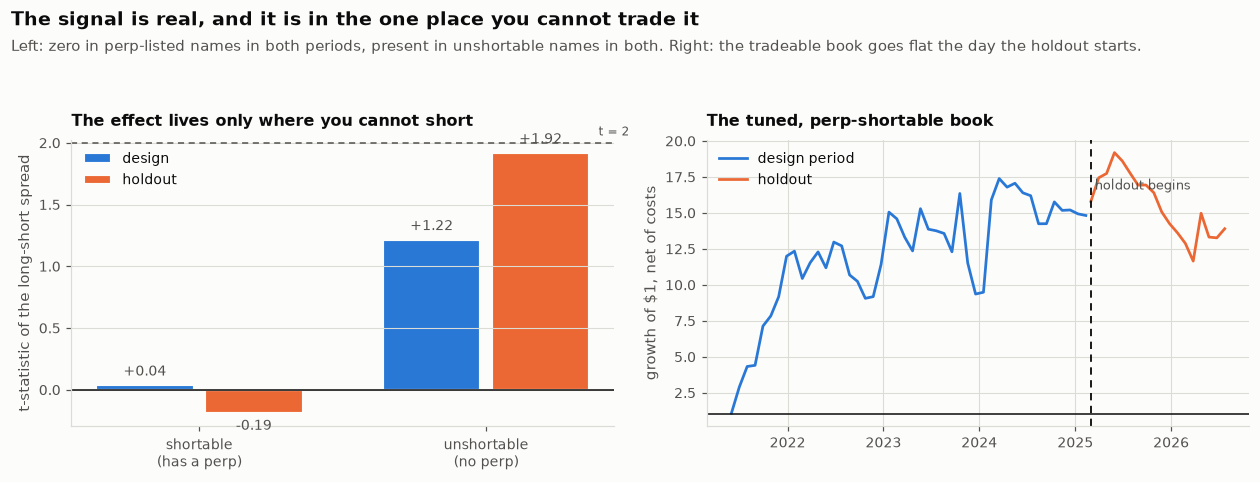

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
piv = WHERE.pivot(index="universe", columns="period", values="t_net")
xx = np.arange(len(piv))
b1 = axes[0].bar(xx - 0.19, piv["design "], 0.34, color=C1, label="design", edgecolor=SURFACE, linewidth=1.4)
b2 = axes[0].bar(xx + 0.19, piv["holdout"], 0.34, color=C2, label="holdout", edgecolor=SURFACE, linewidth=1.4)
for bars in (b1, b2):
    for bar in bars:
        v = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, v + (0.05 if v >= 0 else -0.05),
                     f"{v:+.2f}", ha="center", va="bottom" if v >= 0 else "top",
                     fontsize=9, color=INK_2)
axes[0].axhline(0, color=INK, lw=1.0)
axes[0].axhline(2, color=INK_2, lw=1.0, ls=(0, (4, 3)))
axes[0].text(len(piv) - 0.5, 2.06, "t = 2", fontsize=8, color=INK_2, ha="right")
axes[0].set_xticks(xx, [t.replace(" (", "\n(") for t in piv.index])
axes[0].set_ylabel("t-statistic of the long-short spread")
axes[0].set_title("The effect lives only where you cannot short")
axes[0].legend(loc="upper left"); axes[0].grid(axis="x", visible=False)

eq_d = (1 + des["series"]).cumprod()
eq_h = (1 + hold["series"]).cumprod() * eq_d.iloc[-1]
axes[1].plot(eq_d.index, eq_d, color=C1, label="design period")
axes[1].plot(eq_h.index, eq_h, color=C2, label="holdout")
axes[1].axvline(DESIGN_END, color=INK, lw=1.2, ls=(0, (4, 3)))
axes[1].text(DESIGN_END, eq_d.max(), " holdout begins", fontsize=8.5, color=INK_2, va="top")
axes[1].axhline(1, color=INK, lw=1.0)
axes[1].set_ylabel("growth of $1, net of costs")
axes[1].set_title("The tuned, perp-shortable book")
axes[1].legend(loc="upper left")
figure_titles(fig, "The signal is real, and it is in the one place you cannot trade it",
              "Left: zero in perp-listed names in both periods, present in unshortable names in both. Right: the tradeable book goes flat the day the holdout starts.")
plt.show()

---
# VERDICT

In [14]:
W = 80
hold_short = WHERE[(WHERE.period == "holdout") & (WHERE.universe == "shortable (has a perp)")].iloc[0]
hold_unsh = WHERE[(WHERE.period == "holdout") & (WHERE.universe == "unshortable (no perp)")].iloc[0]
des_short = WHERE[(WHERE.period == "design ") & (WHERE.universe == "shortable (has a perp)")].iloc[0]
des_unsh = WHERE[(WHERE.period == "design ") & (WHERE.universe == "unshortable (no perp)")].iloc[0]

print("=" * W)
print("NO. AND NOW WE KNOW EXACTLY WHY.".center(W))
print("=" * W)
print(f"""
THE OPEN QUESTION IS ANSWERED — AND THE ANSWER WAS THE OPTIMISTIC ONE
{'-'*W}
  Notebook 2 stopped because it could not tell whether the short leg existed.
  It does. {int(listed.notna().sum())} of {len(listed)} tokens have a live perp on OKX or Hyperliquid,
  {int(top40.perp_listed.notna().sum())} of the 40 biggest fee earners do, and ~{share.mean()*100:.0f}% of the eligible cross-
  section is shortable on a given day. Restricting the short leg to perp-listed
  names did not damage the design-period result at all.

  That hypothesis is dead. The strategy fails for a different reason.

THE OPTIMISATION FOUND NOTHING THAT GENERALISED
{'-'*W}
  {len(G)} configurations on the design period: median t {G.t_net.median():+.2f}, best {G.t_net.max():+.2f}, {(G.t_net>2).mean()*100:.0f}% above t=2.
  The same configurations on the holdout: median t {M.t_holdout.median():+.2f}, best {M.t_holdout.max():+.2f},
  {(M.t_holdout>2).mean()*100:.0f}% above t=2 — not one of eighty-one.

  Rank correlation between design-period t and holdout t: {rho.statistic:+.2f} (p={rho.pvalue:.2f}).
  The pre-committed configuration went {des['net_%']:+.2f}%/30d (t={des['t_net']:.2f}) in design and
  {hold['net_%']:+.2f}%/30d (t={hold['t_net']:.2f}) in the holdout. It retained {hold['net_%']/des['net_%']*100:.0f}% of the edge.

  This is what optimisation looks like when there is nothing there to find. The
  in-sample numbers improved; nothing else did.

IT IS NOT A REGIME EXCUSE
{'-'*W}
  Cross-sectional dispersion nearly TRIPLED into the holdout (6.6% -> 16.9% daily)
  and breadth roughly doubled (58 -> 112 names). A long-short factor had more to
  work with, not less, and still produced nothing.

THE SIGNAL IS REAL. IT IS IN THE ONE PLACE YOU CANNOT TRADE IT.
{'-'*W}
  Sorted within perp-listed names only : t {des_short.t_net:+.2f} design, {hold_short.t_net:+.2f} holdout
  Sorted within non-perp names only    : t {des_unsh.t_net:+.2f} design, {hold_unsh.t_net:+.2f} holdout

  Zero in liquid names in both periods. Present in illiquid names in both periods,
  and the only thing that survived out of sample ({hold_unsh['net_%']:+.2f}%/30d, Sharpe {hold_unsh.sharpe:.2f}).

  Fee growth is not a mispricing that arbitrage has missed. It is a liquidity
  premium, and it is priced away precisely where a venue thought the name liquid
  enough to list a perp. That is a coherent economic story, it is consistent
  across both periods, and it is fatal: the alpha and the tradability are
  mutually exclusive by construction.

LONG-ONLY DOES NOT RESCUE IT
{'-'*W}
  Holdout excess over the basket: {LO.loc[(LO.signal=='composite')&(LO.period=='holdout'),'net_%'].iloc[0]:+.2f}%/30d, t={LO.loc[(LO.signal=='composite')&(LO.period=='holdout'),'t_net'].iloc[0]:.2f} — insignificant, and earned
  against a benchmark falling {abs(LO.loc[(LO.signal=='composite')&(LO.period=='holdout'),'bench_%'].iloc[0]):.1f}%/30d. The book still lost money outright.
""")

print("=" * W)
print("WHAT I WOULD AND WOULD NOT DO NEXT")
print("=" * W)
print("""
  WOULD NOT: tune further. Section 5 is the reason. Eighty-one configurations
  produced a design-period median t of +1.45 and a holdout median of -0.57, with
  a rank correlation near zero. More search on this data cannot distinguish a
  real configuration from a lucky one, and every additional variant tried makes
  the best in-sample number look better while meaning less.

  WORTH TESTING, because it follows from the finding rather than fighting it:

  1. TREAT IT AS AN ILLIQUIDITY PREMIUM AND PRICE THE COST HONESTLY. The effect
     is in names with no perp. Fetch spot order books and daily dollar volume for
     that subset and re-run with a realistic impact model instead of a flat
     100bp. If a 6%/30d gross edge survives 300-500bp all-in on $50-100k
     clips, it is a small-capacity strategy worth running at small size. If it
     does not, it is finished. This is the one test that could still change the
     answer, and the flat-cost assumption used throughout is why it has not been
     answered here.

  2. TEST THE PERP-LISTING EVENT ITSELF. If the premium is priced away when a
     perp appears, the listing is an event with a predictable return around it.
     That is a cleaner, more capacity-constrained trade than the factor, and it
     is directly implied by the shortable/unshortable split above.

  3. LET THE HOLDOUT GROW. Eighteen 30-day periods is a weak test in absolute
     terms; it is decisive here only because it agrees with the configuration-rank
     evidence. Re-run in six months with 24 periods before concluding anything
     stronger than "did not confirm".
""")
print("=" * W)
print("BOTTOM LINE")
print("=" * W)
print(f"""  The short leg exists — that question is settled, and favourably. But the
  alpha is not in the shortable names, and no amount of construction tuning
  puts it there. The tradeable book returned {hold['net_%']:+.2f}%/30d out of sample
  against {des['net_%']:+.2f}% in sample, and not one of {len(M)} configurations reached t=2
  on data it had not seen.

  The discovery is real but it is a discovery ABOUT the market, not a strategy
  in it: fee growth predicts crypto returns only where the market is too
  illiquid to arbitrage it. Do not deploy capital on this. The one experiment
  that could still overturn it is a liquidity and impact study on the
  non-perp names — not another backtest on these.""")
print("=" * W)

                        NO. AND NOW WE KNOW EXACTLY WHY.                        

THE OPEN QUESTION IS ANSWERED — AND THE ANSWER WAS THE OPTIMISTIC ONE
--------------------------------------------------------------------------------
  Notebook 2 stopped because it could not tell whether the short leg existed.
  It does. 86 of 200 tokens have a live perp on OKX or Hyperliquid,
  34 of the 40 biggest fee earners do, and ~44% of the eligible cross-
  section is shortable on a given day. Restricting the short leg to perp-listed
  names did not damage the design-period result at all.

  That hypothesis is dead. The strategy fails for a different reason.

THE OPTIMISATION FOUND NOTHING THAT GENERALISED
--------------------------------------------------------------------------------
  108 configurations on the design period: median t +1.45, best +2.57, 12% above t=2.
  The same configurations on the holdout: median t -0.57, best +1.92,
  0% above t=2 — not one of eighty-one.

  Rank correlati